# RegFM Demo: predict gene expression for unseen cell line

This notebook runs RegFM prediction on a unseen cell line.  
Set the local paths below (checkpoint, DNA/TF/expression inputs, tokenizers), then run all cells.

## Setup paths

In [4]:
import os
import sys
from argparse import Namespace
from pathlib import Path

import numpy as np
import torch

# Repo root = directory containing this notebook
ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "main.py").exists():
    raise FileNotFoundError("Please run this notebook from the RegFM repository root.")

sys.path.insert(0, str(ROOT / "src"))
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

# ---------------------------------------------------------------------------
# Edit these paths for your local setup
# ---------------------------------------------------------------------------
KMER = 4

# Config / vocab root (TF & expression tokenizers)
SOURCE = "/path/to/GenomicLLM-config"

# Finetuned checkpoint directory (must contain modelwhole.pth)
MODEL_PATH = "/path/to/checkpoint"

# Shared DNA features
DNA_PATH = "/path/to/dna_features"

# TF chromatin / expression inputs for one cell line
TFCR_PATH = "/path/to/tf_features"
EXP_PATH = "/path/to/exp_features"

DNA_TOKENIZER = "/path/to/dna_tokenizer.json"
DNA_CONFIG = f"/path/to/bert-config-{KMER}/config.json"
TRANS_TOKENIZER = f"{SOURCE}/scBERT_2103TF_config_new/vocab.txt"
TRANS_CONFIG = f"{SOURCE}/scBERT_2103TF_config_new/config.json"
EXP_TOKENIZER = f"{SOURCE}/scBERT_exp_config_256binned_2103TFs/vocab.txt"
EXP_CONFIG = f"{SOURCE}/scBERT_exp_config_256binned_2103TFs/config.json"

PREDICT_DIR = str(ROOT / "demo_output")
SAVE_NAME = "regfm_demo"
os.makedirs(PREDICT_DIR, exist_ok=True)

print(f"model  : {MODEL_PATH}")
print(f"output : {PREDICT_DIR}/pred_results_{SAVE_NAME}.npy")

model  : /path/to/checkpoint
output : /home/gaozijing/program/RegFM/demo_output/pred_results_regfm_demo.npy


## Load tokenizers and configs

In [4]:
from transformers import BertConfig, DNATokenizer
from transformers import glue_output_modes as output_modes
from transformers import glue_processors as processors

from utils import build_dna_tokenizer, predict, set_seed

args = Namespace(
    tfcr_dir=TFCR_PATH,
    dna_dir=DNA_PATH,
    exp_dir=EXP_PATH,
    cis_model_name_or_path=MODEL_PATH,
    trans_model_name_or_path=MODEL_PATH,
    exp_config_name=EXP_CONFIG,
    dna_config_name=DNA_CONFIG,
    trans_tokenizer_name=TRANS_TOKENIZER,
    exp_tokenizer_name=EXP_TOKENIZER,
    dna_tokenizer_name=DNA_TOKENIZER,
    output_dir=MODEL_PATH,
    predict_dir=PREDICT_DIR,
    save_name=SAVE_NAME,
    task_name="genepred",
    do_predict=True,
    do_train=False,
    do_eval=False,
    do_visualcross=False,
    overwrite_cache=False,
    max_seq_length=2112,
    max_dna_seq_length=71680,
    per_gpu_pred_batch_size=1,
    n_process=8,
    hidden_dropout_prob=0.1,
    local_rank=-1,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args.device = device
args.n_gpu = torch.cuda.device_count() if device.type == "cuda" else 0
set_seed(args)

args.task_name = args.task_name.lower()
processor = processors[args.task_name]()
args.output_mode = output_modes[args.task_name]
num_labels = len(processor.get_labels())

config = BertConfig.from_pretrained(
    args.exp_config_name,
    num_labels=num_labels,
    finetuning_task=args.task_name,
)
config.hidden_dropout_prob = args.hidden_dropout_prob
config.attention_probs_dropout_prob = 0.1

tokenizer = DNATokenizer.from_pretrained(args.trans_tokenizer_name)
epi_tokenizer = DNATokenizer.from_pretrained(args.exp_tokenizer_name)
dna_tokenizer = build_dna_tokenizer(args)

print("device:", device)
print("tokenizers loaded.")
print("tf config:", TRANS_CONFIG)

Calling DNATokenizer.from_pretrained() with the path to a single file or url is deprecated
Calling DNATokenizer.from_pretrained() with the path to a single file or url is deprecated


<class 'transformers.tokenization_dna.DNATokenizer'>
<class 'transformers.tokenization_dna.DNATokenizer'>
device: cuda
tokenizers loaded.
tf config: /home/sunyining/program/GenomicLLM/GenomicLLM-config/scBERT_2103TF_config_new/config.json


## Load model

In [5]:
from utils import load_finetuned_checkpoint

model = load_finetuned_checkpoint(args.output_dir, device, config=config)
model.to(device)
model.eval()
print("Model ready.")
print(type(model))

predict(args, model, tokenizer, epi_tokenizer, dna_tokenizer)

Model ready.
<class 'model.RegFM'>


## Run prediction and evaluation

In [9]:
pred_file = os.path.join(PREDICT_DIR, f"pred_results_{SAVE_NAME}.npy")
true_file = os.path.join(PREDICT_DIR, f"dev.tsv")

preds = np.load(pred_file)
groundtruth = pd.read_csv(true_file,sep='\t')['label']

Pearson  r = 0.9541  (p = 0.00e+00)
Spearman ρ = 0.9547  (p = 0.00e+00)


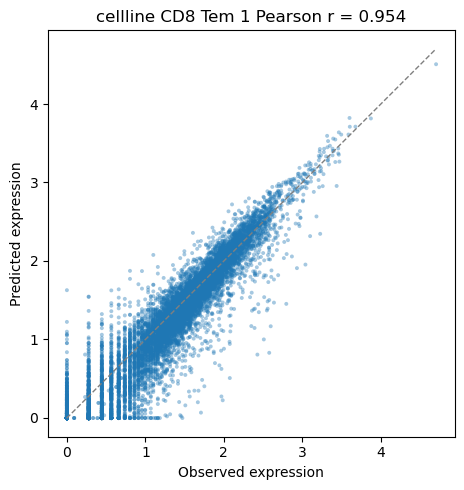

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr, spearmanr


n = min(len(preds), len(groundtruth))
preds = preds[:n]
groundtruth = groundtruth[:n]

r_pearson, p_pearson = pearsonr(preds, groundtruth)
r_spearman, p_spearman = spearmanr(preds, groundtruth)
print(f"Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.2e})")
print(f"Spearman ρ = {r_spearman:.4f}  (p = {p_spearman:.2e})")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(groundtruth, preds, s=8, alpha=0.4, edgecolors="none")
lims = [
    min(groundtruth.min(), preds.min()),
    max(groundtruth.max(), preds.max()),
]
ax.plot(lims, lims, "--", color="gray", linewidth=1)
ax.set_xlabel("Observed expression")
ax.set_ylabel("Predicted expression")
ax.set_title(f"cellline CD8 Tem 1 Pearson r = {r_pearson:.3f}")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()
